In [1]:
import gmsh
import ufl
import pyvista as pv
import numpy as np
import dolfinx.io as dio
import adios4dolfinx

from ufl import inner, grad, div, dot, dx
from scipy.spatial import KDTree
from pathlib import Path
from mpi4py import MPI
from dolfinx import fem, plot, mesh
from dolfinx.fem.petsc import assemble_vector, assemble_matrix
from basix.ufl import element, mixed_element
from petsc4py import PETSc

In [2]:
def map_facet_tags_from_msh_to_bp(meshfile: Path, bpfile: Path, tol: float = 1e-10):
    """
    Map facet tags from a .msh file onto the mesh read from a .bp file.
    Returns
    -------
    domain : dolfinx.Mesh
        The mesh read from the .bp file.
    facet_tags_bp : dolfinx.MeshTags
        Facet tags mapped onto the BP mesh.
    """
    # --- Load both meshes ---
    mesh_msh, _, facet_tags_msh = dio.gmshio.read_from_msh(meshfile, MPI.COMM_WORLD, gdim=2)
    mesh_msh.topology.create_connectivity(mesh_msh.topology.dim - 1, mesh_msh.topology.dim)

    domain = adios4dolfinx.read_mesh(bpfile, MPI.COMM_WORLD)
    domain.topology.create_connectivity(domain.topology.dim - 1, domain.topology.dim)
    tdim = domain.topology.dim

    # --- Compute facet centroids ---
    def facet_centroids(m):
        f2v = m.topology.connectivity(tdim - 1, 0)
        X = m.geometry.x
        nF = m.topology.index_map(tdim - 1).size_local
        C = np.zeros((nF, X.shape[1]))
        for f in range(nF):
            C[f] = X[f2v.links(f)].mean(axis=0)
        return C

    cent_msh = facet_centroids(mesh_msh)
    cent_bp = facet_centroids(domain)

    # --- Match via KDTree ---
    tree = KDTree(cent_bp)
    bp_ids, bp_vals = [], []
    for f_msh, val in zip(facet_tags_msh.indices, facet_tags_msh.values):
        dist, f_bp = tree.query(cent_msh[f_msh])
        if dist < tol:
            bp_ids.append(f_bp)
            bp_vals.append(val)

    facet_tags_bp = mesh.meshtags(domain, tdim - 1,
                                   np.array(bp_ids, np.int32),
                                   np.array(bp_vals, np.int32))

    if MPI.COMM_WORLD.rank == 0:
        print(f"✅ facet tags mapped .msh → .bp | unique values: {np.unique(facet_tags_bp.values)}")

    return domain, facet_tags_bp

In [3]:
y_lim = 1.0
x_lim = 2.0

meshfile = Path("../meshes/rectangle_circular_holes/mesh.msh").resolve()
wind_file = Path("../wind_data/airflow_picard.bp").resolve()

domain, facet_tags = map_facet_tags_from_msh_to_bp(meshfile, wind_file)

# Get tags of physical groups
gmsh.initialize()
gmsh.open(str(meshfile))
phy_groups = gmsh.model.getPhysicalGroups()
name_to_id = {gmsh.model.getPhysicalName(dim, tag): tag for (dim, tag) in phy_groups}
gmsh.finalize()

elem_u = element("Lagrange", domain.basix_cell(), 2, shape=(2,))
elem_p = element("Lagrange", domain.basix_cell(), 1)

mixed_elem = mixed_element([elem_u, elem_p])

W = fem.functionspace(domain, mixed_elem)
W0, W1 = W.sub(0), W.sub(1)

V, V_to_W = W0.collapse() 
V_to_W = np.array(V_to_W, dtype=np.int32)
Q, Q_to_W = W1.collapse()
Q_to_W = np.array(Q_to_W, dtype=np.int32)


nu = fem.Constant(domain, PETSc.ScalarType(1.5e-4))

Info    : Reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'...
Info    : 53 entities
Info    : 835 nodes
Info    : 1678 elements
Info    : Done reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'
✅ facet tags mapped .msh → .bp | unique values: [2 3 4 5 6 7 8 9]
Info    : Reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'...
Info    : 53 entities
Info    : 835 nodes
Info    : 1678 elements
Info    : Done reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'


In [ ]:
# Boundary conditions

# No slip boundary condition
u_D_no_slip = fem.Function(V)
u_D_no_slip.x.array[:] = 0.0
no_slip_names = ["Walls", "Obstacles"]
dofs_local = np.concatenate([facet_tags.find(name_to_id[name]) for name in no_slip_names])
dofs_no_slip = fem.locate_dofs_topological((W0, V), V.mesh.topology.dim - 1, dofs_local)

bc_no_slip = fem.dirichletbc(u_D_no_slip, dofs_no_slip, W0)

# Outflow - zero pressure
p_zero = fem.Function(Q)
p_zero.x.array[:] = 0.0
p_1_facets = ["Outflow"]
dofs_local = np.concatenate([facet_tags.find(name_to_id[name]) for name in p_1_facets])
dofs_out = fem.locate_dofs_topological((W1, Q), V.mesh.topology.dim - 1, dofs_local)

bc_out = fem.dirichletbc(p_zero, dofs_out, W1)

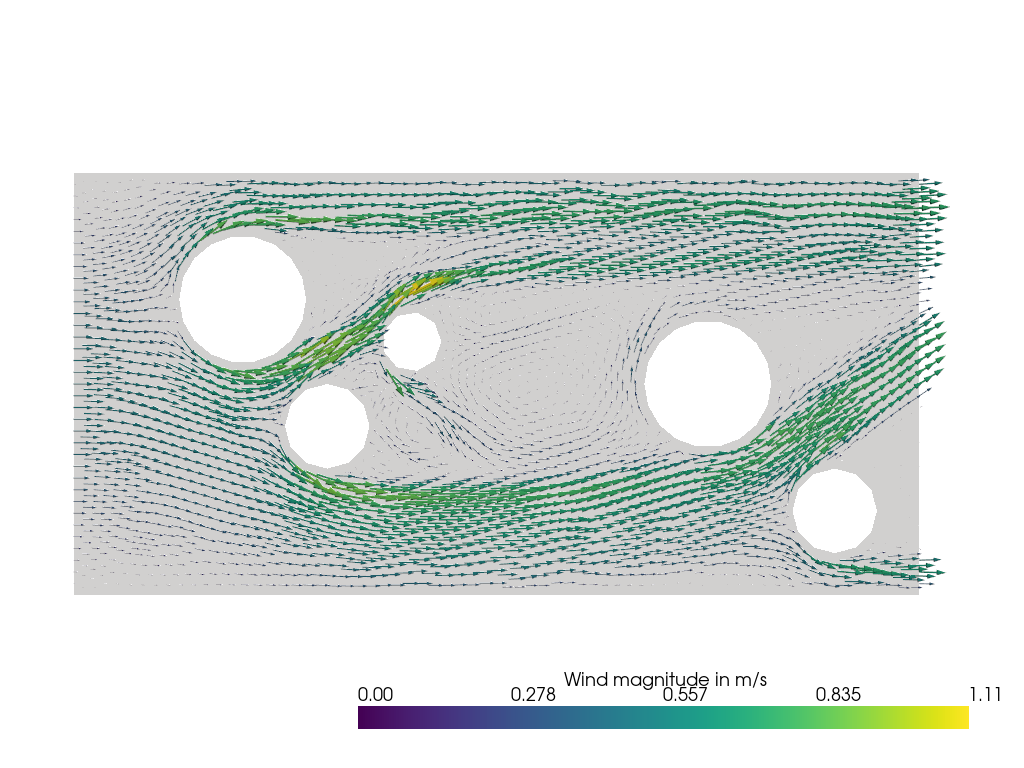

In [10]:
# Load true velocity fields in P2 and P1
u_true = fem.Function(V)
adios4dolfinx.read_function(wind_file, u_true, name="velocity_H2")

w_true = fem.Function(W)
w_true.sub(0).interpolate(u_true)

# Random P2 samples
coords_P2 = V.tabulate_dof_coordinates()
p = 50
rng = np.random.default_rng(5)
sample_ids = rng.choice(len(coords_P2), size=p, replace=False)

x_ids = sample_ids * 2
y_ids = sample_ids * 2 + 1

velocity_ids_V = np.stack((x_ids, y_ids)).T.flatten()
measurement_ids_W = V_to_W[velocity_ids_V]

w_measured = fem.Function(W)
w_measured.x.array[:] = 0.0
w_measured.x.array[measurement_ids_W] = w_true.x.array[measurement_ids_W]

topology, cell_type, geom = plot.vtk_mesh(V)
grid = pv.UnstructuredGrid(topology, cell_type, geom)

wind2d = u_true.x.array.reshape(-1, 2)
wind3d = np.hstack((wind2d, np.zeros((wind2d.shape[0], 1))))
grid.point_data["wind_vectors"] = wind3d

subset = grid.extract_points(np.arange(grid.n_points))
glyphs = subset.glyph(orient="wind_vectors", scale="wind_vectors", factor=0.1)

measured = pv.PolyData(coords_P2[sample_ids])

# --- Plot ---
pl = pv.Plotter()
pl.add_mesh(grid, color="gray", opacity=0.3)
pl.add_mesh(glyphs, scalar_bar_args={"title": "Wind magnitude in m/s"})
#pl.add_mesh(measured, color="red", point_size=10, label="Sample DOFs (P2)")
pl.view_xy()
pl.zoom_camera(1.3)
pl.show()

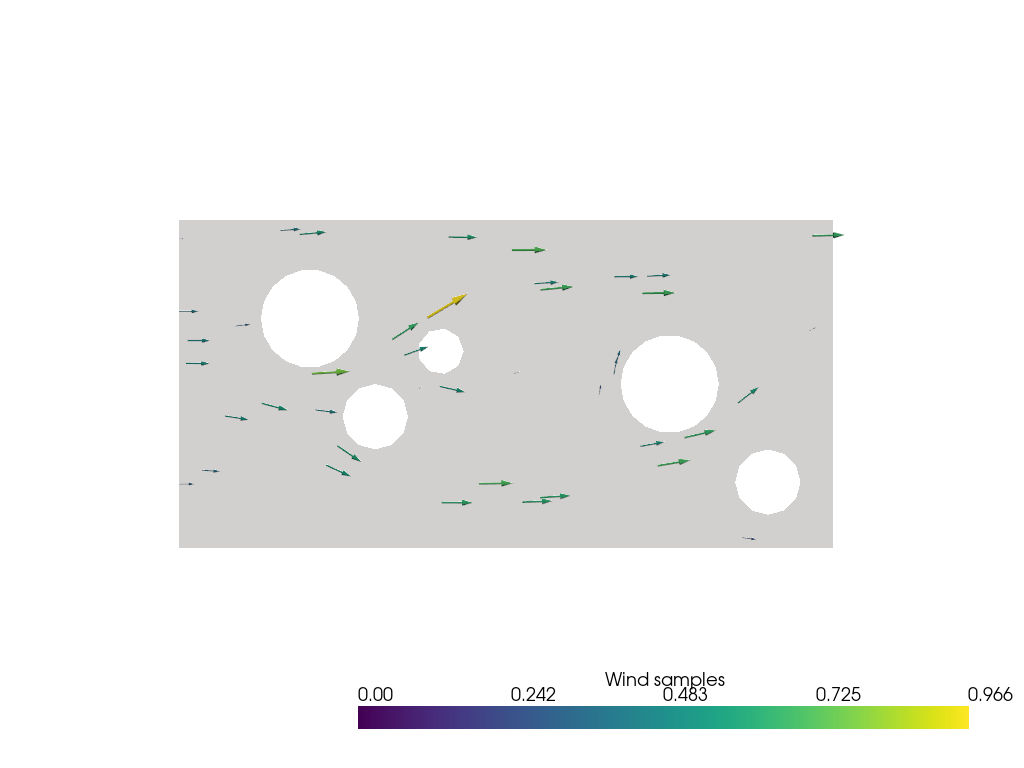

In [6]:
u_measured_V = w_measured.sub(0).collapse()

samples2d = u_measured_V.x.array.reshape(-1, 2)
samples3d = np.hstack((samples2d, np.zeros((samples2d.shape[0], 1))))
grid.point_data["wind_samples"] = samples3d

subset = grid.extract_points(np.arange(grid.n_points))
glyphs = subset.glyph(orient="wind_samples", scale="wind_samples", factor=0.15)

pl = pv.Plotter()
pl.add_mesh(grid, color="gray", opacity=0.3)
pl.add_mesh(glyphs, scalar_bar_args={"title": "Wind samples"})
pl.view_xy()
pl.show()

In [7]:
def build_pde_reg_forms(wh_prev: fem.Function, nu_value: float, beta_val: float, gamma_val: float):
    
    W = wh_prev.function_space
    domain = W.mesh

    nu    = fem.Constant(domain, PETSc.ScalarType(nu_value))
    beta  = fem.Constant(domain, PETSc.ScalarType(beta_val))
    gamma = fem.Constant(domain, PETSc.ScalarType(gamma_val))

    uh_prev, _ = wh_prev.split()
    (u, p) = ufl.TrialFunctions(W)
    (v, q) = ufl.TestFunctions(W)
    
    # Least square FEM
    Rmom_u = -nu*div(grad(u)) + dot(uh_prev, grad(u)) + grad(p)
    Rmom_v = -nu*div(grad(v)) + dot(uh_prev, grad(v)) + grad(q)
    Rdiv_u = div(u); Rdiv_v = div(v)

    a_pde = ( beta*( inner(Rmom_u, Rmom_v) + Rdiv_u*Rdiv_v )
              + gamma*inner(grad(u), grad(v)) ) * dx
    
    zero_vec = fem.Constant(domain, PETSc.ScalarType((0.0,) * domain.geometry.dim))
    L_pde = inner(zero_vec, v) * dx

    return a_pde, L_pde

def assemble_system_with_bcs(a_form: ufl.form.Form, L_form: ufl.form.Form, bcs: list):
    aF, LF = fem.form(a_form), fem.form(L_form)
    A = assemble_matrix(aF, bcs=bcs); A.assemble()
    b = assemble_vector(LF)
    fem.apply_lifting(b, [aF], bcs=[bcs])
    b.ghostUpdate(addv=PETSc.InsertMode.ADD, mode=PETSc.ScatterMode.REVERSE)
    fem.set_bc(b, bcs)

    return A, b

def add_dof_penalty(A: PETSc.Mat, b: PETSc.Vec, 
                    measurement_ids_W: list, w_measured: fem.Function, 
                    alpha_dof: float):
    # S_(i,i) = 1.0 for measured dofs
    S = PETSc.Mat().createAIJ(A.getSizes(), nnz=1, comm=A.comm); S.setUp()
    for i in map(int, measurement_ids_W):
        S.setValue(i, i, 1.0)
    S.assemble()

    # Adjust rhs: S * u_meas
    rhs_add = w_measured.x.petsc_vec.duplicate()
    S.mult(w_measured.x.petsc_vec, rhs_add)

    # Update linear system: A += α S,  b += α S u_meas
    A.axpy(alpha_dof, S, structure=PETSc.Mat.Structure.DIFFERENT_NONZERO_PATTERN)
    b.axpy(alpha_dof, rhs_add)

Step 0: step norm = 2.01e+01
Step 1: step norm = 6.70e+00
Step 2: step norm = 4.25e+00
Step 3: step norm = 2.94e+00
Step 4: step norm = 2.95e+00
Step 5: step norm = 3.52e+00
Step 6: step norm = 4.08e+00
Step 7: step norm = 4.15e+00
Step 8: step norm = 4.39e+00
Step 9: step norm = 4.59e+00
-----
Stopped after 10 iterations.


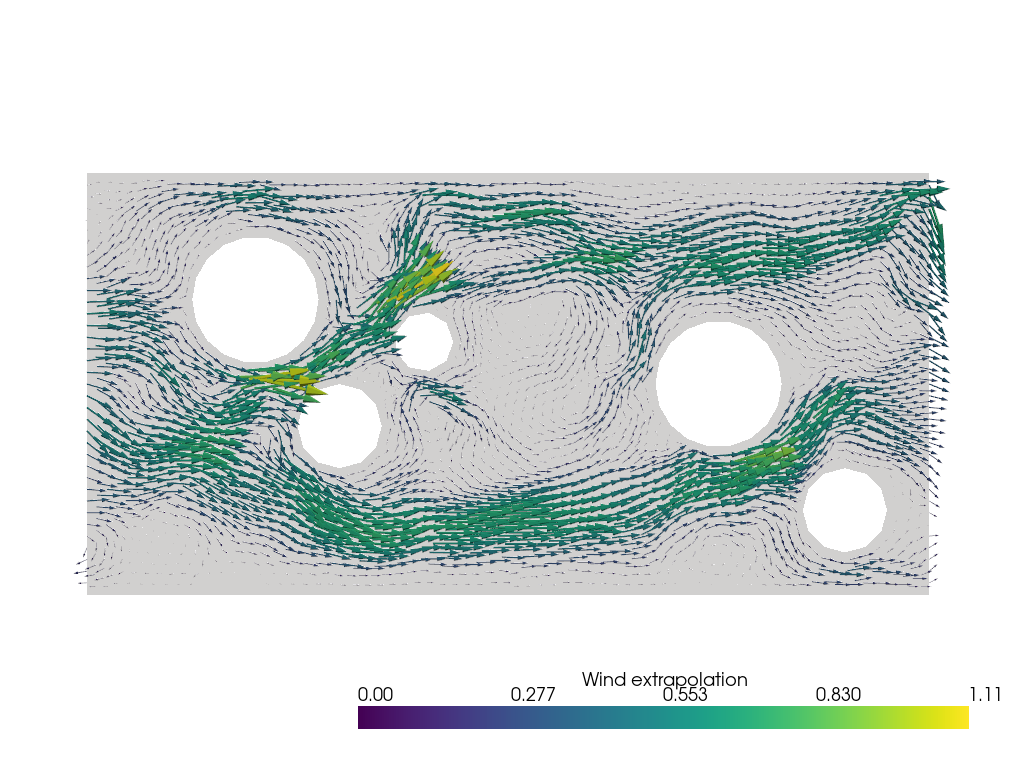

In [8]:
maxit = 10

wh = fem.Function(W)
wh.x.array[:] = 0.0

wh_prev = fem.Function(W)
wh_prev.x.array[:] = 0.0

alpha = 1e3 # data misfit weight
beta  = 1e2 # pde residual weight
gamma = 1e-3 # regularization weight

criteria_diff = 1e-2

bcs = [bc_no_slip, bc_out] 

for k in range(maxit):

    a_pde, L_pde = build_pde_reg_forms(wh_prev, nu_value=1.5e-4, beta_val=beta, gamma_val=gamma)
    
    A, b = assemble_system_with_bcs(a_pde, L_pde, bcs)

    add_dof_penalty(A, b, measurement_ids_W, w_measured, alpha)

    ksp = PETSc.KSP().create(A.comm); ksp.setOperators(A)
    ksp.setType("preonly"); ksp.getPC().setType("lu")
    ksp.setFromOptions()
    ksp.solve(b, wh.x.petsc_vec)
    wh.x.petsc_vec.assemblyBegin(); wh.x.petsc_vec.assemblyEnd()
    wh.x.array[:] = wh.x.petsc_vec.getArray(readonly=True)

    step_norm = np.linalg.norm(wh_prev.x.array - wh.x.array)
    print(f"Step {k}: step norm = {step_norm:.2e}")
    if step_norm < criteria_diff: 
        print(f"-----\nConverged after {k+1} steps.")
        break

    if k == maxit - 1:
        print(f"-----\nStopped after {maxit} iterations.")
    wh_prev.x.array[:] = wh.x.array


# Visualize result 
u_final = wh.sub(0).collapse() 
samples2d = u_final.x.array.reshape(-1, 2) 
samples3d = np.hstack((samples2d, np.zeros((samples2d.shape[0], 1)))) 
grid.point_data["wind_extrapolation"] = samples3d 
subset = grid.extract_points(np.arange(grid.n_points)) 
glyphs = subset.glyph(orient="wind_extrapolation", scale="wind_extrapolation", factor=0.15) 
pl = pv.Plotter() 
pl.add_mesh(grid, color="gray", opacity=0.3) 
pl.add_mesh(glyphs, scalar_bar_args={"title": "Wind extrapolation"}) 
pl.view_xy() 
pl.zoom_camera(1.3)
pl.show()
    